In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Working...")

arr = np.array([1,2,3,4,5])
x = np.linspace(-5,5,4000)
y = np.sin(2*np.pi*x)
y1 = np.sin(2*np.pi*x + np.radians(180))
fig,axes = plt.subplots(2,2, figsize = (15,10))
axes[0][0].plot(x,y)
axes[1][0].plot(x,y1)
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Working...")

arr = np.array([1,2,3,4,5])
x = np.linspace(-1, 1,20)
y = pow(np.e, x)
y1 = np.sin(2*np.pi*x + np.radians(180))
y_rev = np.flip(y)

def shift(s):
    return pow(np.e, x+s)

fig,axes = plt.subplots(5,2, figsize = (15,10))
axes[0][0].bar(x,y, width = 0.08)
axes[1][0].bar(x,y_rev, width = 0.08)


y_even = y + y_rev
y_even /= 2
y_odd = y - y_rev
y_odd /= 2
axes[0][1].bar(x,y_even, width = 0.08)
axes[1][1].bar(x,y_odd, width = 0.08)

axes[2][0].bar(x,shift(3), width = 0.08)
axes[3][0].bar(x, shift(-3), width = 0.08)
axes[4,0].bar(x, shift(0), width = 0.08)

plt.show()
print(y[0] - (y_even[0] + y_odd[0]))

In [ ]:
g = [1,2,3,4]
g = np.array(g)
print(5*g)

In [ ]:
import numpy as np

arr = np.array([10, 20, 30, 40])

print(np.searchsorted(arr, 25))

Enter alpha and beta to plot y(t) = x(alpha*t + beta).
Type 'q' at any prompt to quit.



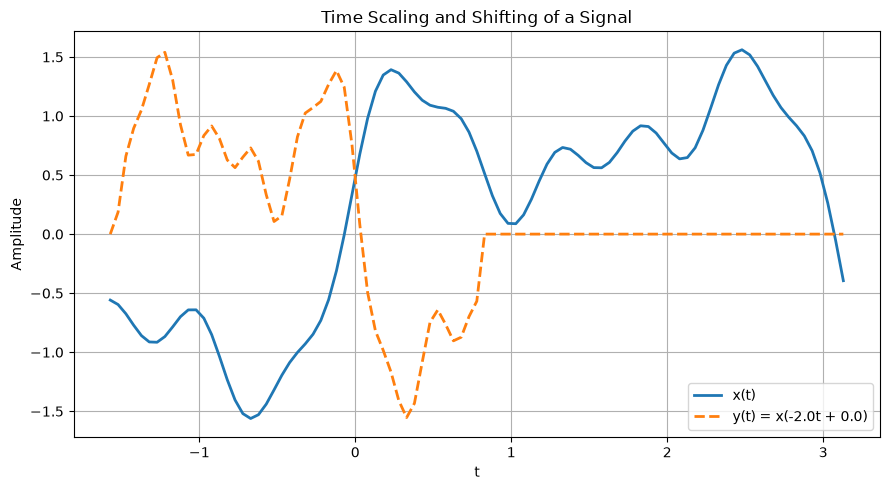

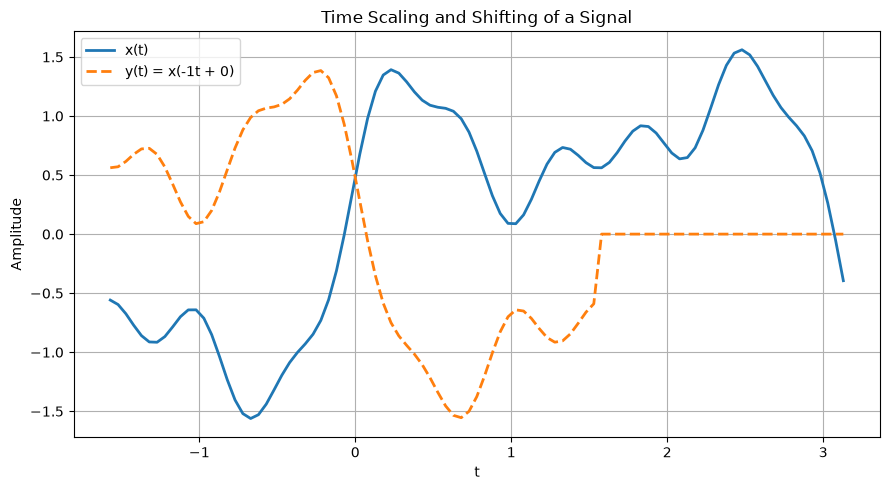

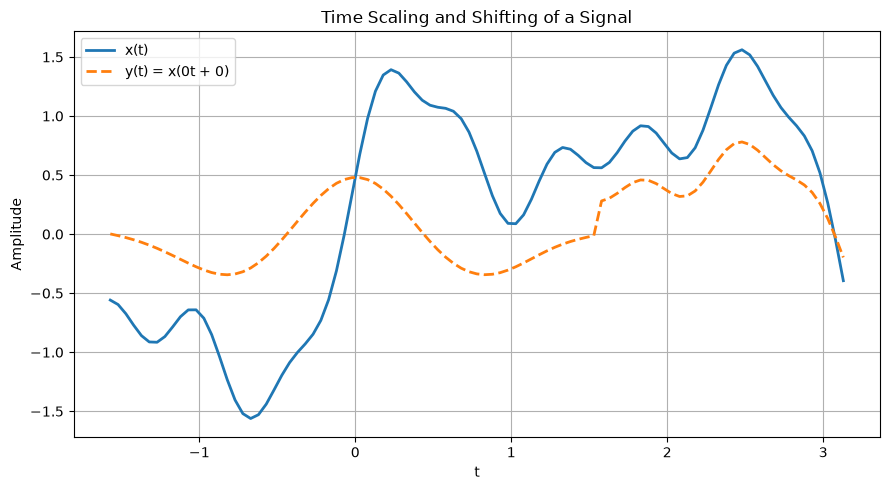

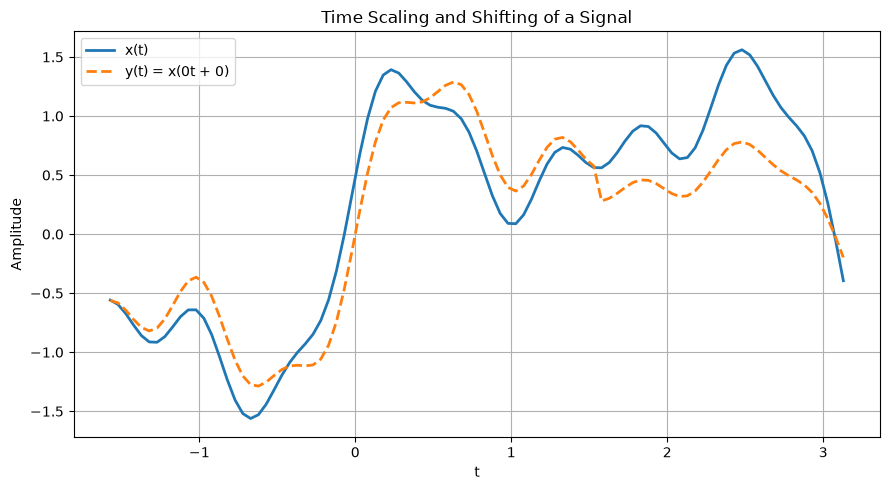

Exiting.


In [31]:
import numpy as np
import matplotlib.pyplot as plt

DT = 0.05 # sampling interval for the time axis
T_MIN, T_MAX = -np.pi/2, np.pi # x(t) is defined only on this range

def generate_time_axis(t_min=T_MIN, t_max=T_MAX, dt=DT):
    # if t_min > (-t_max):
    #     t_min = -t_max

    # if t_max < -t_min:
    #     t_max = -t_min
    return np.arange(t_min, t_max + dt / 2, dt)


def base_signal(t):
    x = (
        np.sin(t)
        + 0.7 * np.sin(3*t + 0.5)
        + 0.4 * np.cos(5*t - 1.2)
        + 0.2 * np.sin(11*t)
    )
    x[(t < T_MIN) | (t > T_MAX)] = 0
    return x

def interpolate_signal(t, x, query_t):
    query_t = np.asarray(query_t)

    y = np.zeros_like(query_t, dtype=float)

    mask = (query_t >= t[0]) & (query_t <= t[-1])

    if np.any(mask):
        q = query_t[mask]

        b = np.searchsorted(t, q)
        b = np.clip(b, 1, len(t) - 1)
        a = b - 1

        y[mask] = x[a] + (q - t[a]) * (x[b] - x[a]) / (t[b] - t[a])

    return y

def transform_signal(t, x, alpha, beta):
    
    # TODO: implement transformation
    t_new = t * alpha
    t_new = t_new + beta

    # t_new = np.clip(t_new, t[0], t[-1])

    x_new = interpolate_signal(t, x, t_new)

    y = x_new
    return y

def even_odd_signal(t, x):
    # Evaluate x(-t)
    x_neg = interpolate_signal(t, x, -t)
    plot_signals(t, x, x_neg, -1, 0)

    # Even component
    x_even = (x + x_neg) / 2

    # Odd component
    x_odd = (x - x_neg) / 2

    return x_even, x_odd

def plot_signals(t, x, y, alpha, beta):
    plt.figure(figsize=(9, 5))
    plt.plot(t, x, label="x(t)", linewidth=2)
    plt.plot(t, y, label=f"y(t) = x({alpha}t + {beta})", linewidth=2, linestyle="--")
    plt.title("Time Scaling and Shifting of a Signal")
    plt.xlabel("t")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def main():
    t = generate_time_axis()
    x = base_signal(t)

    print("Enter alpha and beta to plot y(t) = x(alpha*t + beta).")
    print("Type 'q' at any prompt to quit.\n")

    while True:
        
        # TODO: complete the loop
        cin = input()
        if (cin == 'q'):
            break

        a, b = [float(x) for x in cin.split()]
        
        y = transform_signal(t, x, a, b)
        plot_signals(t, x, y, a, b)
        
        even, odd = even_odd_signal(t, x)
        plot_signals(t, x, even, 0, 0)
        plot_signals(t, x, odd, 0, 0)
        break
    

    print("Exiting.")


if __name__ == "__main__":
    main()

In [ ]:
t = np.array([0, 2, 5, 8])
x = np.array([0, 4, 10, 16])

query_t = np.array([1, 3, 6])

print(interpolate_signal(t, x, query_t))